In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from google.colab import drive

drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/'

X_train = np.load(DRIVE + 'X_train_lasso.npy')
X_test  = np.load(DRIVE + 'X_test_lasso.npy')
y_train = pd.read_csv(DRIVE + 'y_train.csv').squeeze()
y_test  = pd.read_csv(DRIVE + 'y_test.csv').squeeze()
train_clusters = np.load(DRIVE + 'train_clusters.npy')
test_clusters  = np.load(DRIVE + 'test_clusters.npy')
feature_names  = pd.read_csv(DRIVE + 'selected_features.csv').squeeze().tolist()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Unique clusters: {np.unique(train_clusters)}")

Mounted at /content/drive
X_train: (9196, 37)
X_test:  (2299, 37)
Unique clusters: [0 1 2]


In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
    acc   = accuracy_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred)
    auc   = roc_auc_score(y_true, y_prob)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print(classification_report(y_true, y_pred))
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc}

all_results = []

In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
    acc   = accuracy_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred)
    auc   = roc_auc_score(y_true, y_prob)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    print(classification_report(y_true, y_pred))
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc}

all_results = []

In [ ]:
print("=" * 50)
print("EXPERIMENT 1: Global Models (no clustering)")
print("=" * 50)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
all_results.append(evaluate_model(
    'Exp1 - Logistic Regression',
    y_test, lr.predict(X_test), lr.predict_proba(X_test)[:,1]
))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
all_results.append(evaluate_model(
    'Exp1 - Random Forest',
    y_test, rf.predict(X_test), rf.predict_proba(X_test)[:,1]
))

xgb = XGBClassifier(n_estimators=100, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)
all_results.append(evaluate_model(
    'Exp1 - XGBoost',
    y_test, xgb.predict(X_test), xgb.predict_proba(X_test)[:,1]
))


EXPERIMENT 1: Global Models (no clustering)

Model: Exp1 - Logistic Regression
  Accuracy:  0.7434
  F1 Score:  0.6946
  ROC-AUC:   0.8205
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      1277
           1       0.74      0.66      0.69      1022

    accuracy                           0.74      2299
   macro avg       0.74      0.73      0.74      2299
weighted avg       0.74      0.74      0.74      2299


Model: Exp1 - Random Forest
  Accuracy:  0.7495
  F1 Score:  0.7070
  ROC-AUC:   0.8298
              precision    recall  f1-score   support

           0       0.76      0.81      0.78      1277
           1       0.74      0.68      0.71      1022

    accuracy                           0.75      2299
   macro avg       0.75      0.74      0.74      2299
weighted avg       0.75      0.75      0.75      2299


Model: Exp1 - XGBoost
  Accuracy:  0.7521
  F1 Score:  0.7164
  ROC-AUC:   0.8370
              precision    recall  

In [ ]:
print("=" * 50)
print("EXPERIMENT 2: Global Models + Cluster as Feature")
print("=" * 50)

X_train_exp2 = np.hstack([X_train, train_clusters.reshape(-1, 1)])
X_test_exp2  = np.hstack([X_test,  test_clusters.reshape(-1, 1)])

print(f"Feature shape with cluster added: {X_train_exp2.shape}")

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train_exp2, y_train)
all_results.append(evaluate_model(
    'Exp2 - Logistic Regression + Cluster',
    y_test, lr2.predict(X_test_exp2), lr2.predict_proba(X_test_exp2)[:,1]
))

rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train_exp2, y_train)
all_results.append(evaluate_model(
    'Exp2 - Random Forest + Cluster',
    y_test, rf2.predict(X_test_exp2), rf2.predict_proba(X_test_exp2)[:,1]
))

xgb2 = XGBClassifier(n_estimators=100, random_state=42,
                      eval_metric='logloss', verbosity=0)
xgb2.fit(X_train_exp2, y_train)
all_results.append(evaluate_model(
    'Exp2 - XGBoost + Cluster',
    y_test, xgb2.predict(X_test_exp2), xgb2.predict_proba(X_test_exp2)[:,1]
))


EXPERIMENT 2: Global Models + Cluster as Feature
Feature shape with cluster added: (9196, 38)

Model: Exp2 - Logistic Regression + Cluster
  Accuracy:  0.7434
  F1 Score:  0.6959
  ROC-AUC:   0.8207
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      1277
           1       0.74      0.66      0.70      1022

    accuracy                           0.74      2299
   macro avg       0.74      0.74      0.74      2299
weighted avg       0.74      0.74      0.74      2299


Model: Exp2 - Random Forest + Cluster
  Accuracy:  0.7534
  F1 Score:  0.7112
  ROC-AUC:   0.8319
              precision    recall  f1-score   support

           0       0.76      0.81      0.78      1277
           1       0.74      0.68      0.71      1022

    accuracy                           0.75      2299
   macro avg       0.75      0.75      0.75      2299
weighted avg       0.75      0.75      0.75      2299


Model: Exp2 - XGBoost + Cluster
  Accuracy:  0.

In [ ]:
print("=" * 50)
print("EXPERIMENT 3: Separate Models Per Persona")
print("=" * 50)

y_pred_exp3  = np.zeros(len(y_test))
y_prob_exp3  = np.zeros(len(y_test))

persona_results = {}

for cluster_id in np.unique(train_clusters):
    train_mask = train_clusters == cluster_id
    test_mask  = test_clusters == cluster_id

    X_tr = X_train[train_mask]
    y_tr = y_train[train_mask]
    X_te = X_test[test_mask]
    y_te = y_test[test_mask]

    if len(X_te) == 0:
        print(f"  Cluster {cluster_id}: no test samples, skipping")
        continue

    model = XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric='logloss', verbosity=0)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:,1]

    y_pred_exp3[test_mask] = preds
    y_prob_exp3[test_mask] = probs

    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds)
    auc = roc_auc_score(y_te, probs)
    persona_results[cluster_id] = {'Accuracy': acc, 'F1': f1, 'ROC-AUC': auc}
    print(f"  Cluster {cluster_id}: Accuracy={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f} (n={len(X_te)})")

all_results.append(evaluate_model(
    'Exp3 - Per-Persona XGBoost',
    y_test, y_pred_exp3.astype(int), y_prob_exp3
))



EXPERIMENT 3: Separate Models Per Persona
  Cluster 0: Accuracy=0.7515, F1=0.6456, AUC=0.8131 (n=1175)
  Cluster 1: Accuracy=0.7371, F1=0.7195, AUC=0.8020 (n=175)
  Cluster 2: Accuracy=0.7376, F1=0.7603, AUC=0.8232 (n=949)

Model: Exp3 - Per-Persona XGBoost
  Accuracy:  0.7447
  F1 Score:  0.7104
  ROC-AUC:   0.8233
              precision    recall  f1-score   support

           0       0.77      0.78      0.77      1277
           1       0.72      0.70      0.71      1022

    accuracy                           0.74      2299
   macro avg       0.74      0.74      0.74      2299
weighted avg       0.74      0.74      0.74      2299



In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("=" * 60)
print("FULL RESULTS SUMMARY")
print("=" * 60)
print(results_df.to_string(index=False))

results_df.to_csv(DRIVE + 'model_results.csv', index=False)

FULL RESULTS SUMMARY
                               Model  Accuracy       F1  ROC-AUC
                      Exp1 - XGBoost  0.752066 0.716418 0.836962
            Exp2 - XGBoost + Cluster  0.748586 0.716667 0.835523
      Exp2 - Random Forest + Cluster  0.753371 0.711156 0.831898
                Exp1 - Random Forest  0.749456 0.707019 0.829772
          Exp3 - Per-Persona XGBoost  0.744672 0.710409 0.823347
Exp2 - Logistic Regression + Cluster  0.743367 0.695876 0.820723
          Exp1 - Logistic Regression  0.743367 0.694617 0.820463


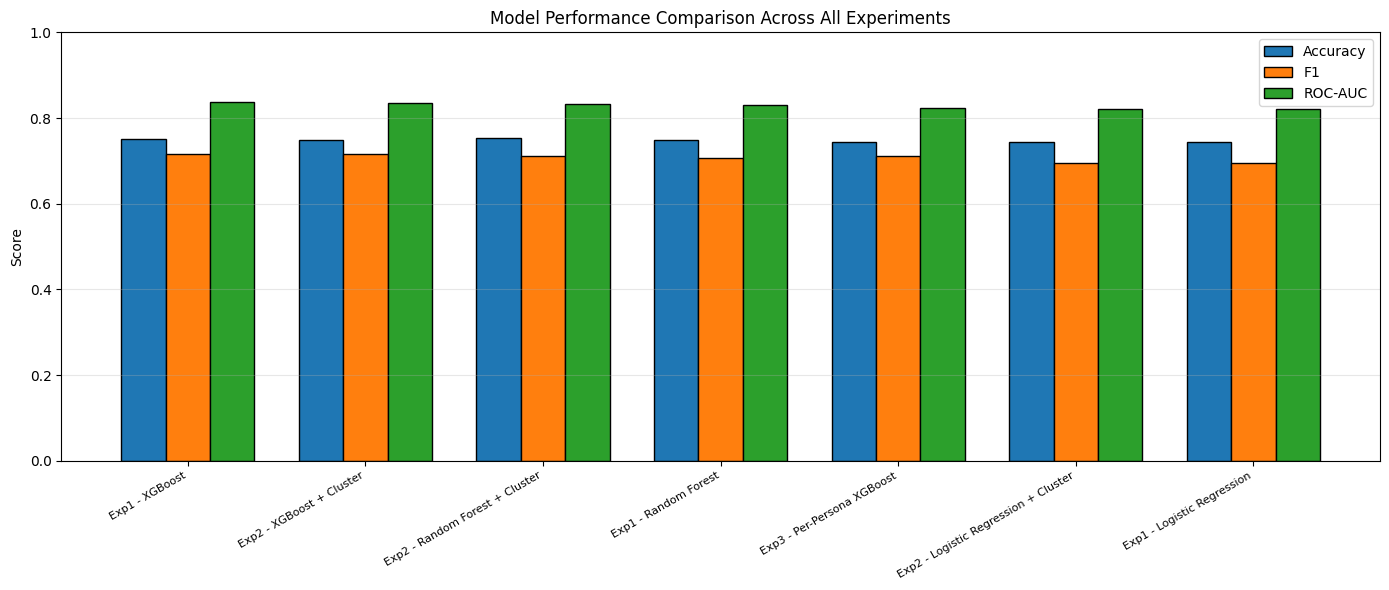

In [ ]:
metrics = ['Accuracy', 'F1', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric, edgecolor='black')

ax.set_title('Model Performance Comparison Across All Experiments')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df['Model'], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(DRIVE + 'model_comparison.png', dpi=150)
plt.show()

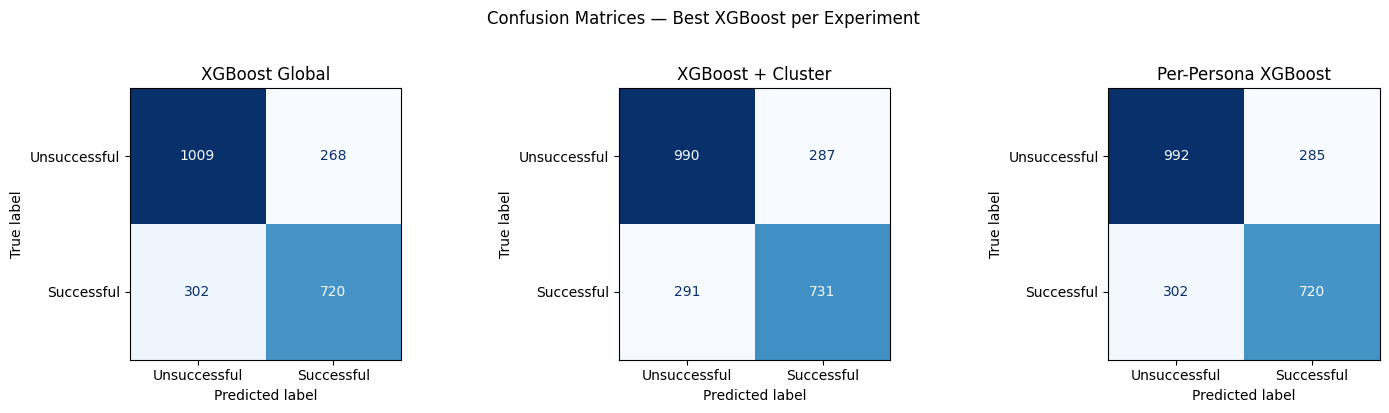

In [ ]:
best_models = {
    'Exp1': (xgb,  X_test,      'XGBoost Global'),
    'Exp2': (xgb2, X_test_exp2, 'XGBoost + Cluster'),
    'Exp3': (None, None,        'Per-Persona XGBoost'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (exp, (model, X_te, title)) in zip(axes, best_models.items()):
    if model is not None:
        preds = model.predict(X_te)
    else:
        preds = y_pred_exp3.astype(int)

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Unsuccessful', 'Successful'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Confusion Matrices — Best XGBoost per Experiment', y=1.02)
plt.tight_layout()
plt.savefig(DRIVE + 'confusion_matrices.png', dpi=150)
plt.show()

In [ ]:
persona_names = {0: 'Blockbusters', 1: 'Indie/Niche', 2: 'Mid-Tier'}

print("Per-Persona Performance (Experiment 3):")
print(f"{'Persona':<20} {'Accuracy':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 52)

for cluster_id, metrics in persona_results.items():
    name = persona_names.get(cluster_id, f'Cluster {cluster_id}')
    print(f"{name:<20} {metrics['Accuracy']:>10.4f} {metrics['F1']:>10.4f} {metrics['ROC-AUC']:>10.4f}")

print("\nThis table goes directly into your paper's Results section ✓")

Per-Persona Performance (Experiment 3):
Persona                Accuracy         F1    ROC-AUC
----------------------------------------------------
Blockbusters             0.7515     0.6456     0.8131
Indie/Niche              0.7371     0.7195     0.8020
Mid-Tier                 0.7376     0.7603     0.8232

This table goes directly into your paper's Results section ✓


In [ ]:
persona_df = pd.DataFrame(persona_results).T
persona_df.index = [persona_names.get(i, f'Cluster {i}') for i in persona_df.index]
persona_df.to_csv(DRIVE + 'persona_results.csv')
